In [1]:
from wrf import (to_np, get_cartopy, latlon_coords, getvar)
from matplotlib.pyplot import get_cmap
import matplotlib.pyplot as plt
import cartopy.feature as cf
from netCDF4 import Dataset
import cartopy.crs as crs
import cartopy

import numpy as np
import matplotlib.pyplot as plt
import os
import sys

### Visualization Example

In [2]:
def plot_pred_vs_target(pred,
                        target,
                        t=0,
                        d05_path="../files/wrfout_d05_2015-10-25_12%3A00%3A00",
                        title="Predicción vs Target",
                        cmap=get_cmap("jet"),
                        vmin=None,
                        vmax=None):
    """
    Plot prediction and target side by side for both U10 and V10 components.

    Displays a 2x2 grid: rows correspond to components (U10, V10),
    columns correspond to prediction and target respectively.

    Parameters
    ----------
    pred : np.ndarray
        Predicted fields, shape (T, H, W, 2), where [..., 0]=U10, [..., 1]=V10.
    target : np.ndarray
        Target fields, same shape as pred.
    t : int, optional
        Time index to visualize. Default is 0.
    d05_path : str, optional
        Path to the WRF NetCDF file used for geolocation and projection.
    title : str, optional
        Main figure title.
    cmap : Colormap, optional
        Colormap. Default is "jet".
    vmin, vmax : float or None, optional
        Color scale limits per component. If None, derived from target at time t.
    """
    # --- Geolocation ---
    d05            = Dataset(d05_path)
    wind_05        = getvar(d05, "HGT")
    lats, lons     = latlon_coords(wind_05)
    cart_proj      = get_cartopy(wind_05)
    lons_np        = to_np(lons)[6:, 10:]
    lats_np        = to_np(lats)[6:, 10:]

    # --- Components ---
    components = [
        (pred[t, :, :, 0], target[t, :, :, 0], "U10"),
        (pred[t, :, :, 1], target[t, :, :, 1], "V10"),
    ]

    # --- Style ---
    plt.style.use('ggplot')
    plt.rcParams.update({'xtick.labelsize': 20, 'ytick.labelsize': 20})

    fig, axs = plt.subplots(2, 2, figsize=[30, 30],
                            subplot_kw={'projection': cart_proj})

    for row, (pred_slice, target_slice, label) in enumerate(components):
        vmin_ = vmin if vmin is not None else target_slice.min()
        vmax_ = vmax if vmax is not None else target_slice.max()

        panels = [(pred_slice,   f"Predicción — {label}"),
                  (target_slice, f"Target — {label}")]

        for col, (data, panel_label) in enumerate(panels):
            ax = axs[row, col]
            ax.add_feature(cf.COASTLINE, linewidth=2)
            ax.coastlines('10m', linewidth=2)

            mesh = ax.pcolormesh(lons_np, lats_np, data,
                                 transform=crs.PlateCarree(),
                                 cmap=cmap, vmin=vmin_, vmax=vmax_)

            cbar = fig.colorbar(mesh, ax=ax, fraction=0.04, pad=0.01)
            cbar.set_label(f"{label} (m/s)", fontsize=25)

            gl = ax.gridlines(draw_labels=True, dms=True,
                              x_inline=False, y_inline=False)
            gl.right_labels = False
            gl.top_labels   = False
            ax.set_title(panel_label, fontsize=30)

    fig.suptitle(f"{title}  |  t={t}", fontsize=42)
    plt.tight_layout(rect=[0, 0, 1, 1.02])
    plt.show()

In [3]:
y_pred_path = "extra/Y_pred_example.npy"

assert os.path.exists(y_pred_path), (
    f"Y_pred not found at '{y_pred_path}'. "
    "Please run Unet_prediction.py before executing this script."
)

y_pred = np.load(y_pred_path)
y_target= np.load('extra/Y_validation_map_example.npy')

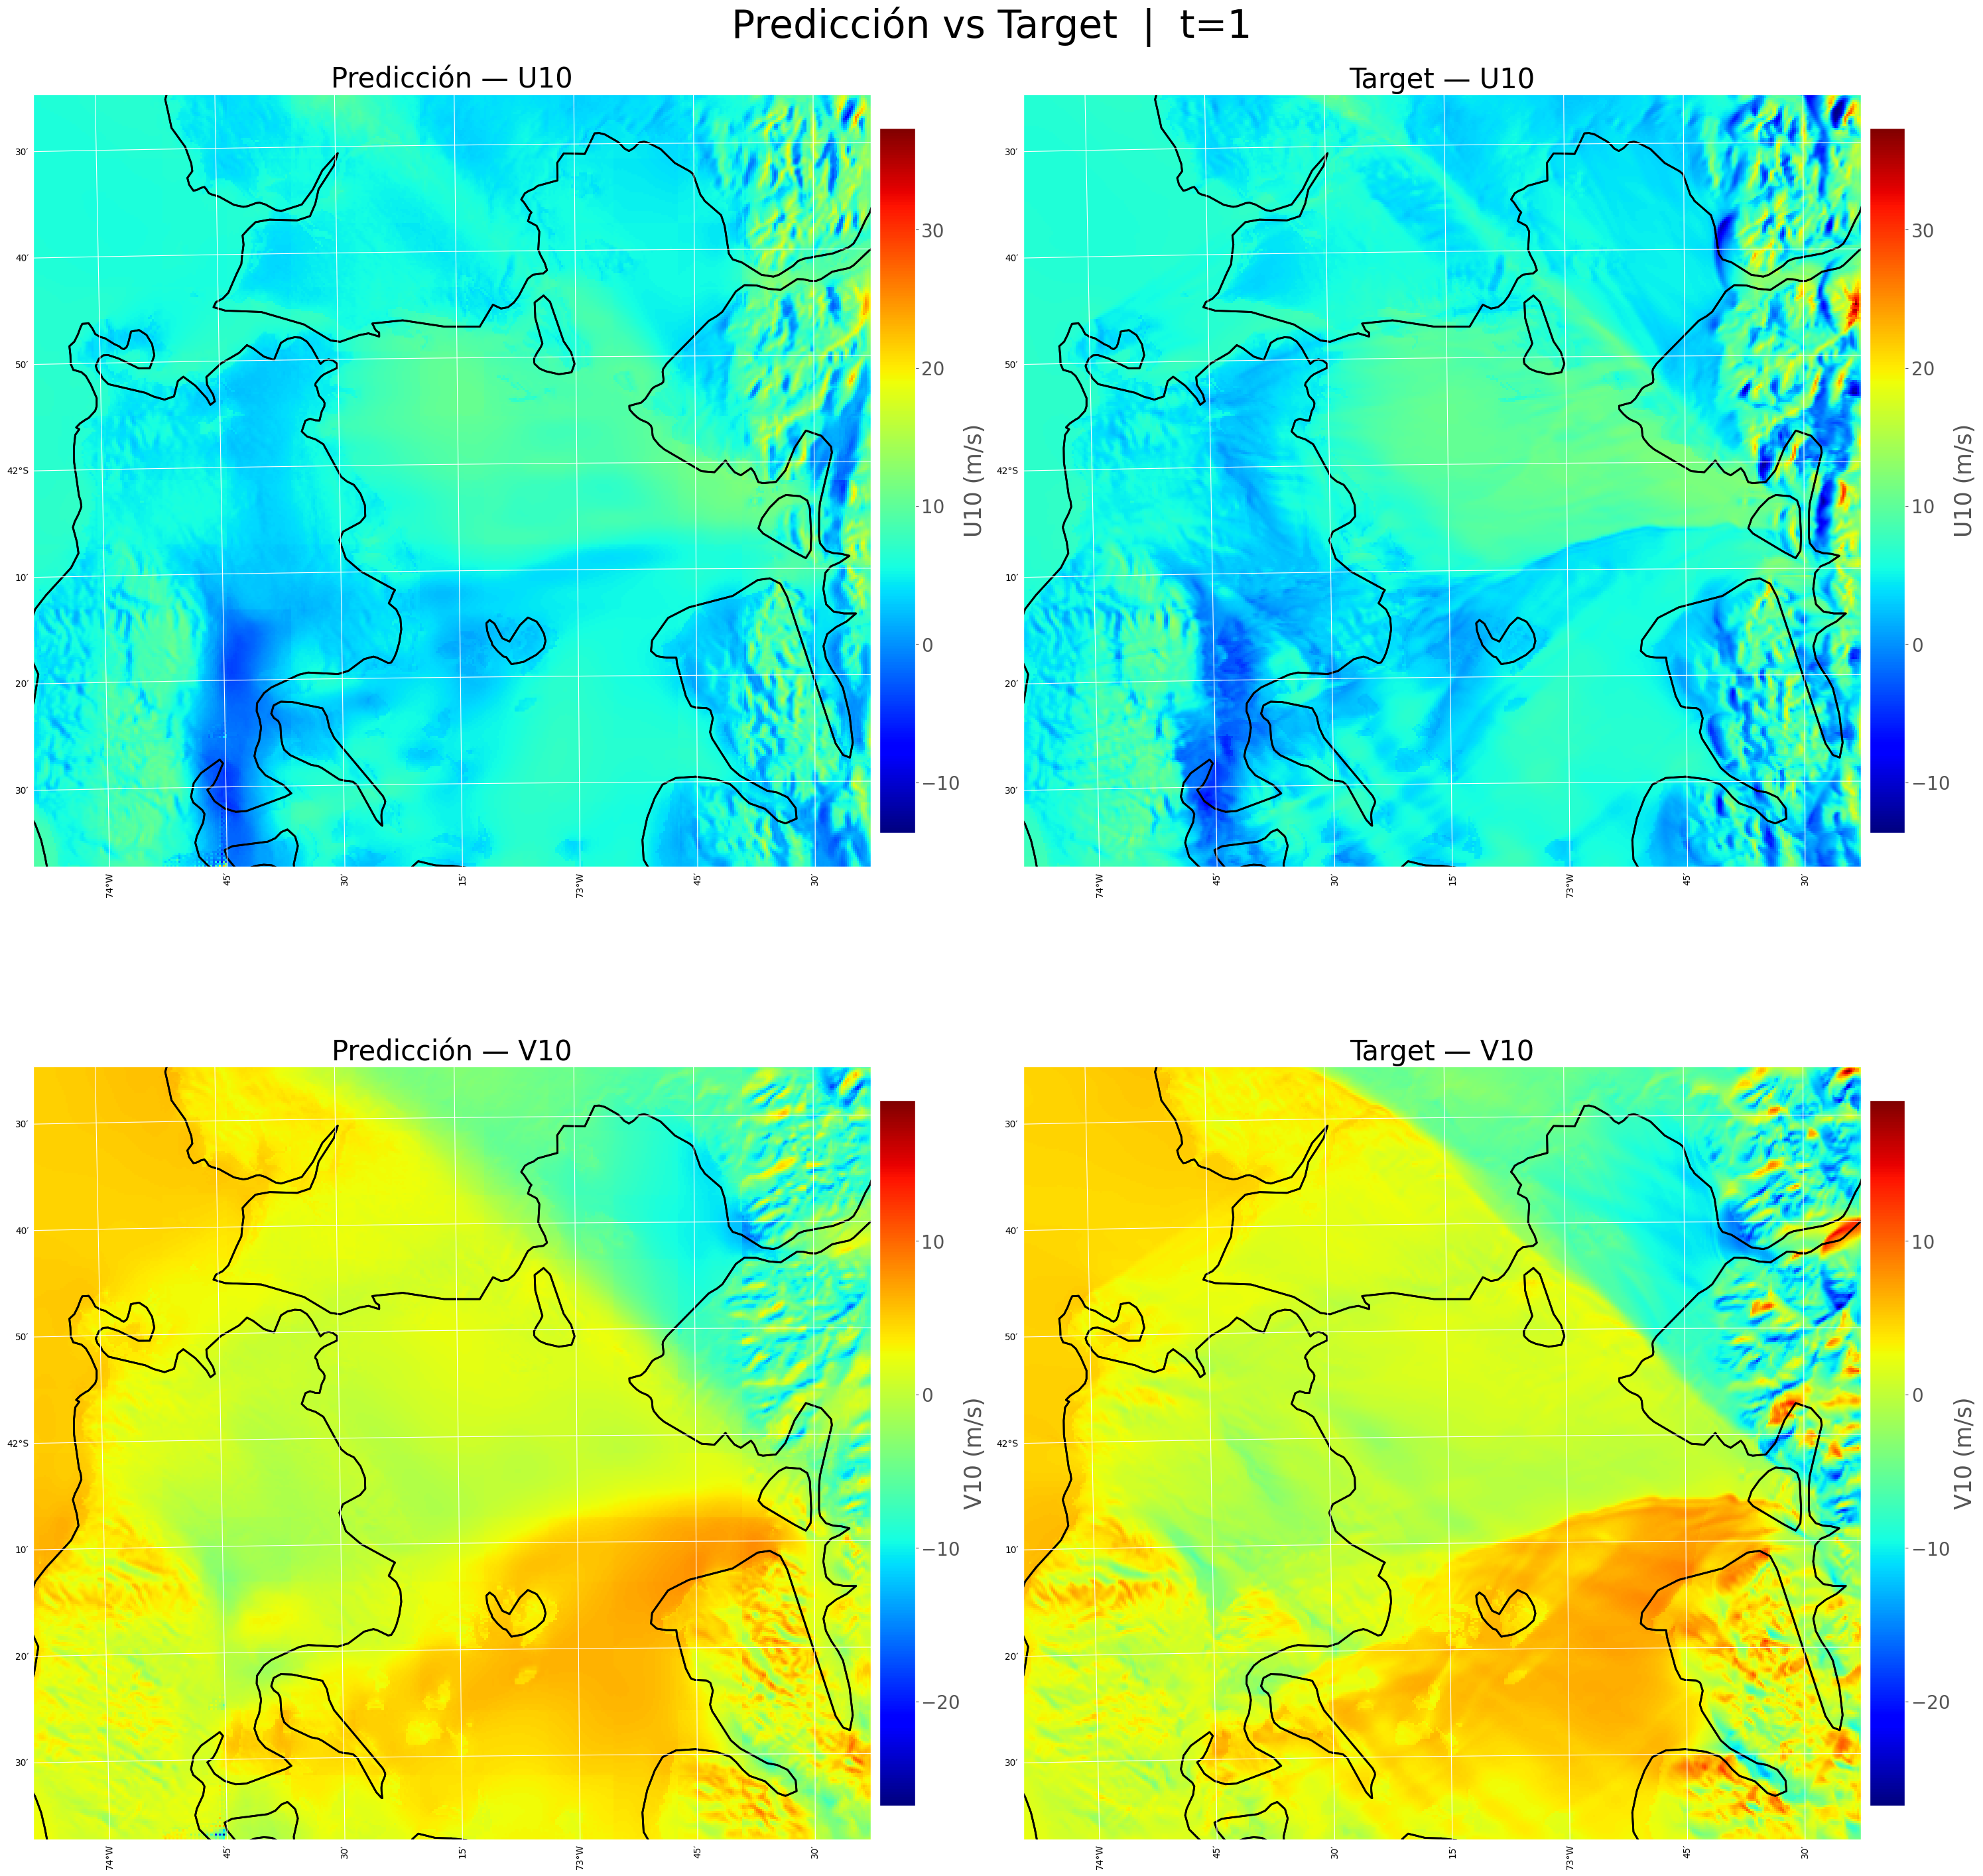

In [7]:
#t in [0,...,113]
plot_pred_vs_target(y_pred[::-1], y_target[::-1], t=1)